In [125]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [88]:
# read the data
df = pd.read_csv('/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv')

print('data size before removing nan values:', df.shape[0])

# remove nan values
df = df.dropna()

print('data size after removing nan values:', df.shape[0])
print(df.head(2))

data size before removing nan values: 237
data size after removing nan values: 237
   No  Method  Grade  Bar size (mm)  Sleeve length (mm)  Outer diameter (mm)  \
0   1       0     60          32.26                 0.0                  0.0   
1   2       0     60          32.26                 0.0                  0.0   

   Temperature (c)  Yield stress (MPa)  Ultimate strength (MPa)  \
0               25          481.254059               814.270837   
1               25          495.733050               804.618177   

   Ultimate strain (%)  
0                 10.5  
1                  9.3  


In [96]:

##  Remove outliers based on the following criteria:
n_before = len(df)

df_clean = df[
    (df["Ultimate strain (%)"] <= 14)
    &
    (df["Ultimate strength (MPa)"] >= 200)
    &
    (df["Yield stress (MPa)"] <= 680)#680)
    &
    (df["Yield stress (MPa)"] >= 350)
].copy()

n_after = len(df_clean)

print(f"Rows before: {n_before}")
print(f"Rows after : {n_after}")
print(f"Removed    : {n_before - n_after}")

## Drop the "Yield stress (MPa)" column as it is not a target variable and has many missing values.
df_clean = df_clean.drop(columns=["Yield stress (MPa)"]).copy()

Rows before: 192
Rows after : 192
Removed    : 0


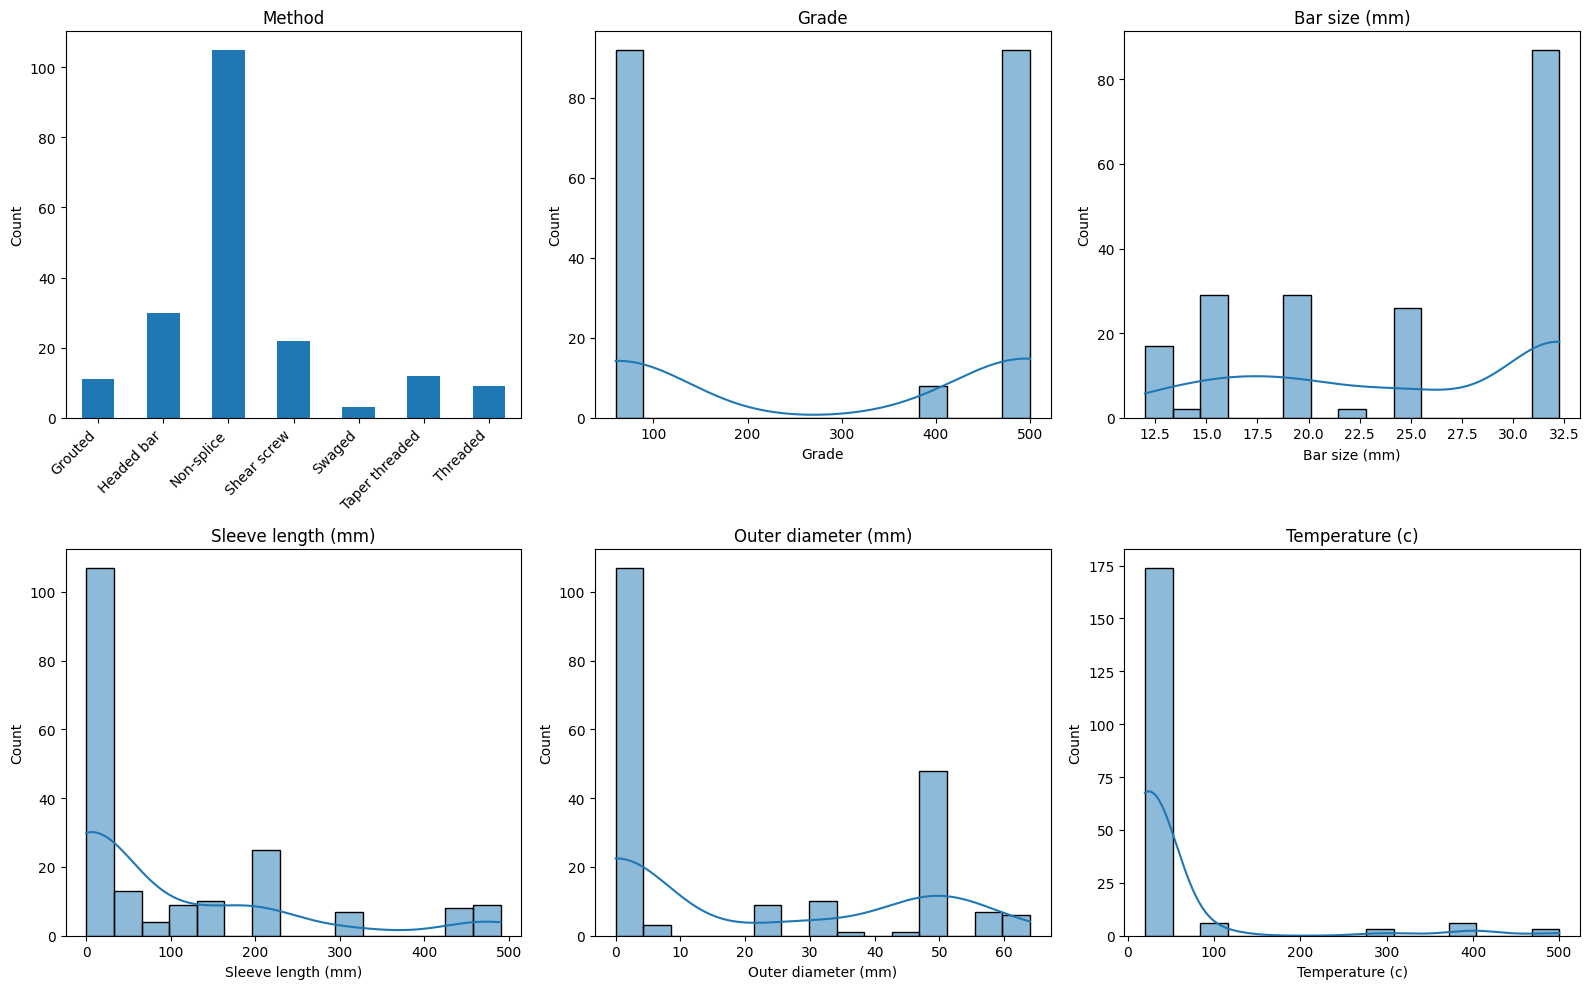

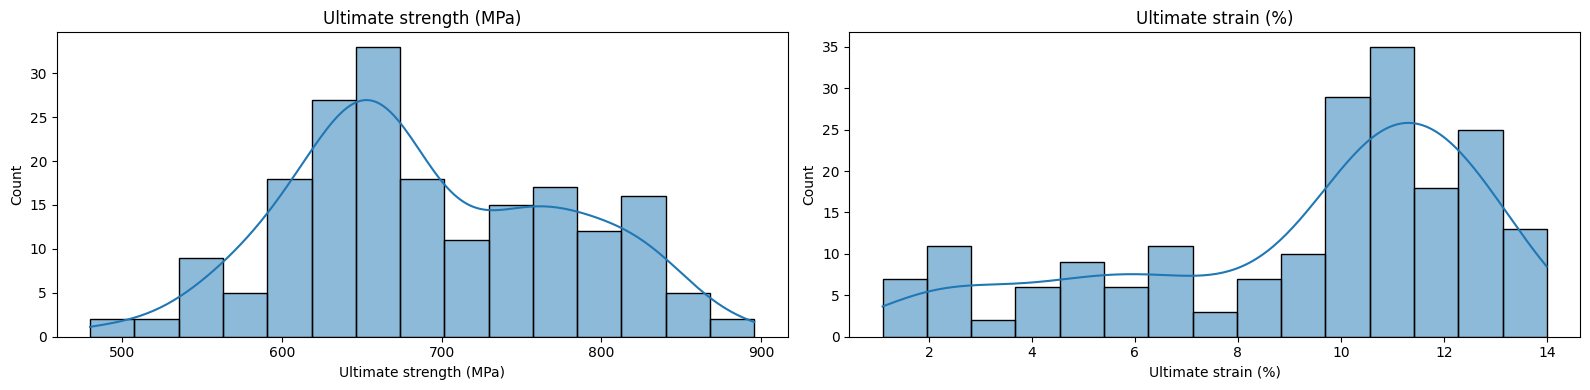

In [112]:
##======================================== Histograms of Inputs and Outputs ========================================


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Method Labels
# ============================================================

method_labels = {
    0: 'Non-splice',
    1: 'Taper threaded',
    2: 'Grouted',
    3: 'Shear screw',
    4: 'Threaded',
    5: 'Headed bar',
    6: 'Swaged'
}

# ============================================================
# Input and Output Columns
# ============================================================

input_cols = [
    'Method',
    'Grade',
    'Bar size (mm)',
    'Sleeve length (mm)',
    'Outer diameter (mm)',
    'Temperature (c)'
]

output_cols = [
    # 'Yield stress (MPa)',
    'Ultimate strength (MPa)',
    'Ultimate strain (%)'
]

# ============================================================
# HISTOGRAMS OF INPUTS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(input_cols):

    ax = axes[i]

    if col == 'Method':

        counts = (
            df_clean[col]
            .map(method_labels)
            .value_counts()
            .sort_index()
        )

        counts.plot(
            kind='bar',
            ax=ax
        )

        ax.set_ylabel('Count')
        ax.set_xlabel('')

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha='right'
        )

    else:

        sns.histplot(
            data=df_clean,
            x=col,
            bins=15,
            kde=True,
            ax=ax
        )

    ax.set_title(col)

plt.tight_layout()
plt.show()

# ============================================================
# HISTOGRAMS OF OUTPUTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, col in zip(axes, output_cols):

    sns.histplot(
        data=df_clean,
        x=col,
        bins=15,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

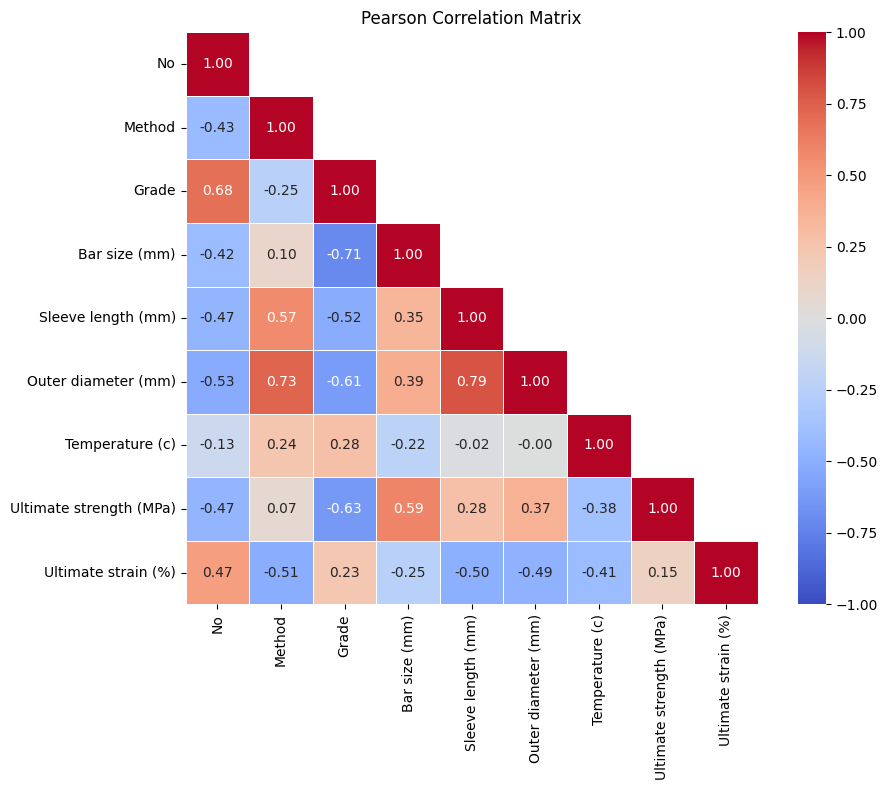

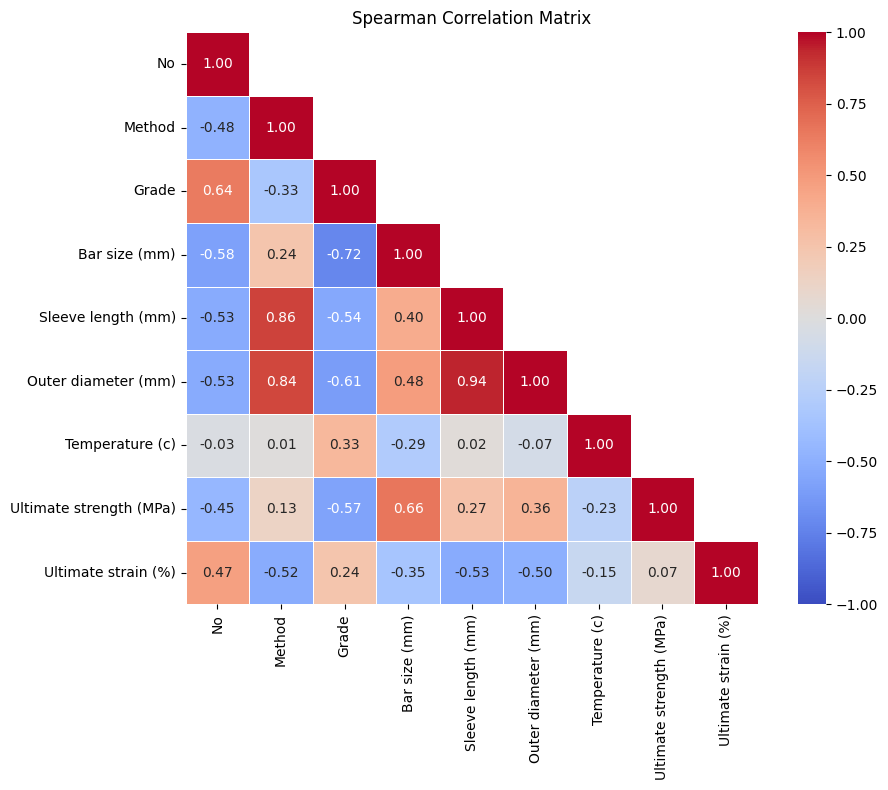

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Select numeric columns
# ============================================================

df_num = df_clean.select_dtypes(include=np.number)

# ============================================================
# Pearson Correlation
# ============================================================

pearson_corr = df_num.corr(method='pearson')

mask = np.triu(
    np.ones_like(pearson_corr, dtype=bool),
    k=1  # keep diagonal, hide upper triangle
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# Spearman Correlation
# ============================================================

spearman_corr = df_num.corr(method='spearman')

mask = np.triu(
    np.ones_like(spearman_corr, dtype=bool),
    k=1
)

plt.figure(figsize=(10,8))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

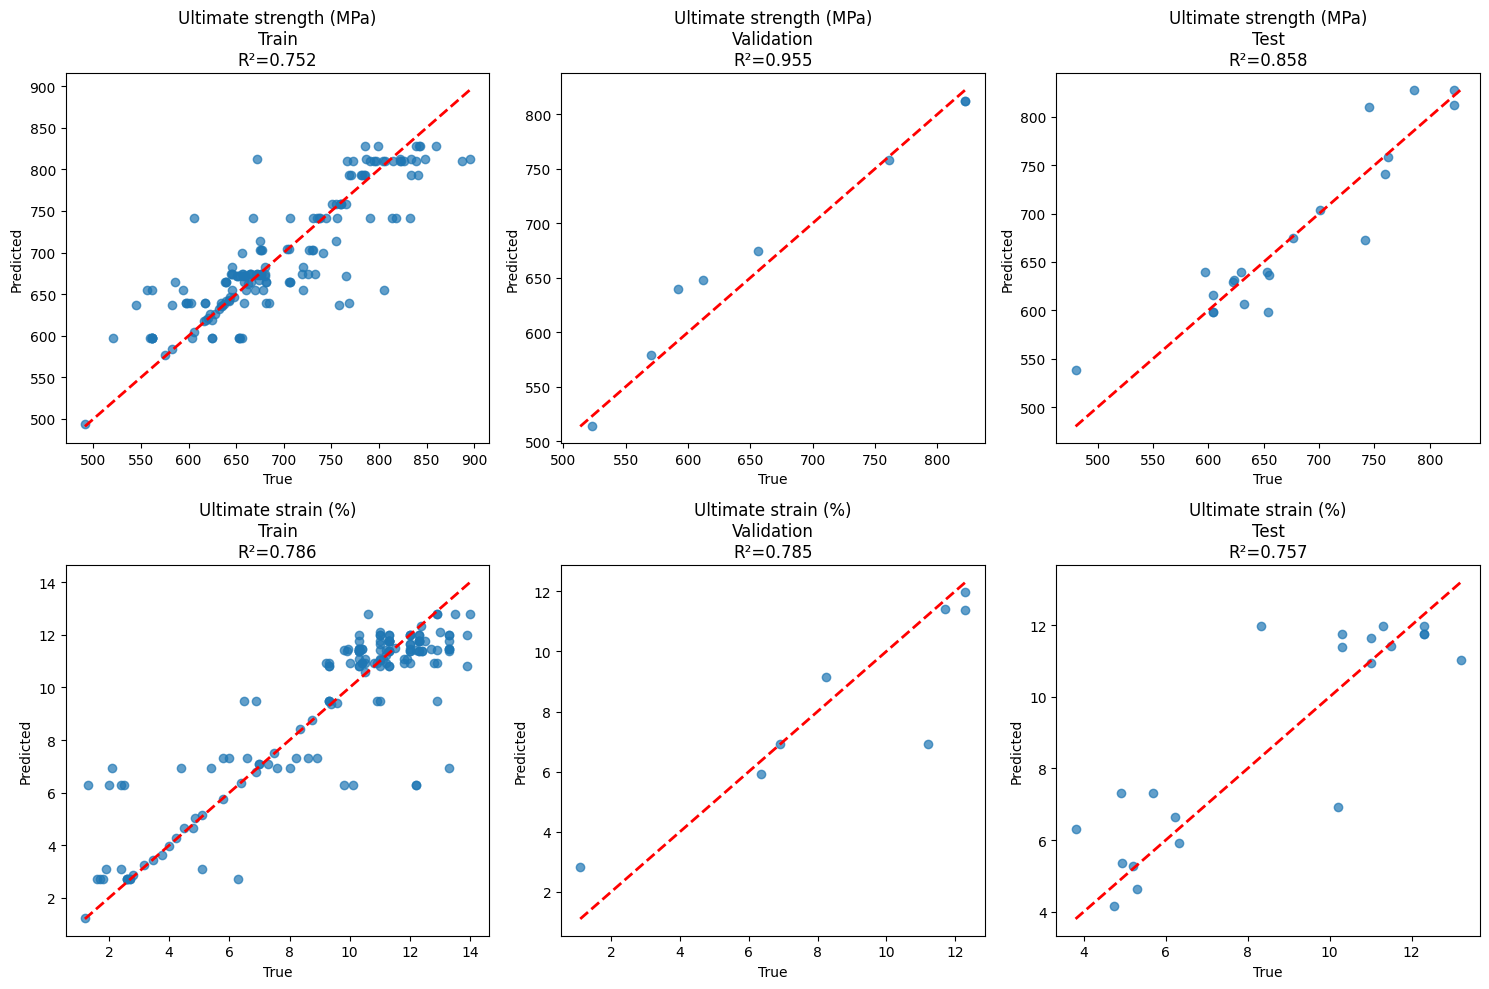


Performance Metrics
                    Target     Dataset        R2       RMSE          MSE
0  Ultimate strength (MPa)       Train  0.752260  41.446201  1717.787597
1  Ultimate strength (MPa)  Validation  0.954774  23.303784   543.066347
2  Ultimate strength (MPa)        Test  0.858054  31.854195  1014.689722
3      Ultimate strain (%)       Train  0.785755   1.593605     2.539578
4      Ultimate strain (%)  Validation  0.784598   1.703807     2.902959
5      Ultimate strain (%)        Test  0.756669   1.540107     2.371928


In [106]:
####### -----------------------------XGBoost------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# =============================================================================
# USER SETTINGS
# =============================================================================

# file_path = "/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv"

targets = [
    # "Yield stress (MPa)",
    "Ultimate strength (MPa)",
    "Ultimate strain (%)"
]

# Features
feature_cols = [
    "Method",
    # "Grade",
    "Bar size (mm)",
    "Sleeve length (mm)",
    "Outer diameter (mm)",
    "Temperature (c)"
]

# -----------------------------------------------------------------------------
# Hyperparameters for Yield Stress Model
# -----------------------------------------------------------------------------

params_fy = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,         
    "colsample_bytree": 0.8,
    "random_state": 10#420
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strength Model
# -----------------------------------------------------------------------------

params_fu = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 40
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strain Model
# -----------------------------------------------------------------------------

params_eps = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 40#40
}

# =============================================================================
# LOAD DATA
# =============================================================================

# df = pd.read_csv(file_path)
df = df_clean

X = df[feature_cols]

# One-hot encoding for categorical columns
X = pd.get_dummies(X, drop_first=True)

# =============================================================================
# TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp = train_test_split(
    X,
    test_size=0.15,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.70,
    random_state=42
)

# =============================================================================
# TRAINING LOOP
# =============================================================================

param_dict = {
    "Yield stress (MPa)": params_fy,
    "Ultimate strength (MPa)": params_fu,
    "Ultimate strain (%)": params_eps
}

results = []

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

for row_idx, target in enumerate(targets):

    y = df[target]

    y_train = y.loc[X_train.index]
    y_val = y.loc[X_val.index]
    y_test = y.loc[X_test.index]

    model = XGBRegressor(**param_dict[target])

    model.fit(
        X_train,
        y_train
    )

    # -------------------------------------------------------------------------
    # Predictions
    # -------------------------------------------------------------------------

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    datasets = [
        ("Train", y_train, pred_train),
        ("Validation", y_val, pred_val),
        ("Test", y_test, pred_test)
    ]

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    for col_idx, (name, y_true, y_pred) in enumerate(datasets):

        r2 = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)

        results.append([
            target,
            name,
            r2,
            rmse,
            mse
        ])

        ax = axes[row_idx, col_idx]

        ax.scatter(
            y_true,
            y_pred,
            alpha=0.7
        )

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            linewidth=2
        )

        ax.set_title(
            f"{target}\n{name}\nR²={r2:.3f}"
        )

        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# =============================================================================
# PERFORMANCE TABLE
# =============================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Target",
        "Dataset",
        "R2",
        "RMSE",
        "MSE"
    ]
)

print("\nPerformance Metrics")
print(results_df)

# =============================================================================
# SAVE RESULTS
# =============================================================================

# results_df.to_csv(
#     "XGBoost_Performance.csv",
#     index=False
# )

# print("\nSaved: XGBoost_Performance.csv")

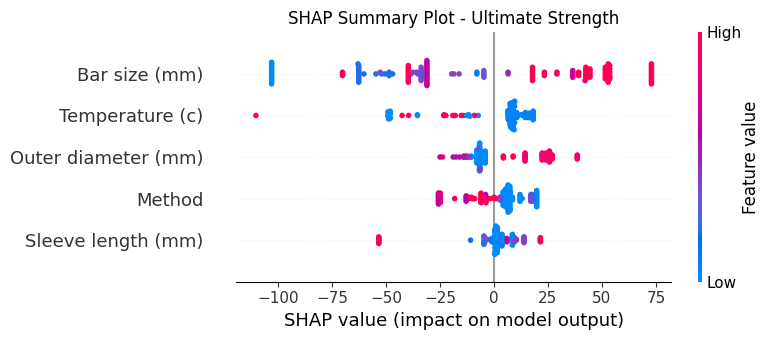

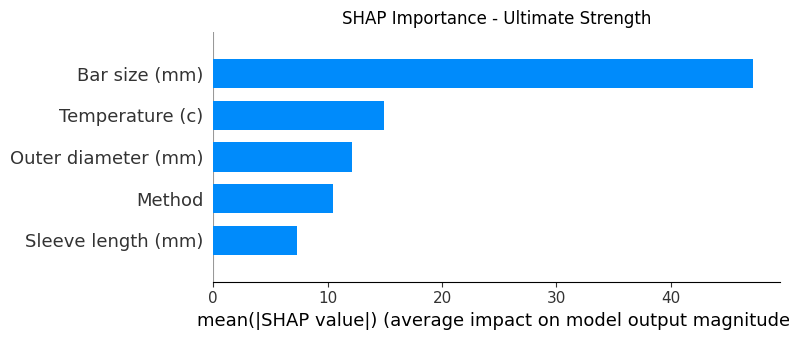

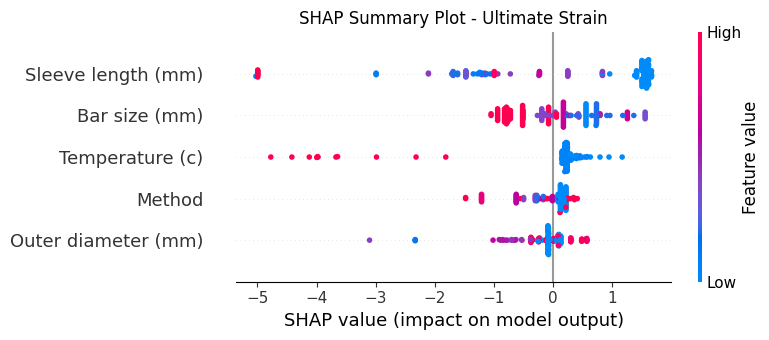

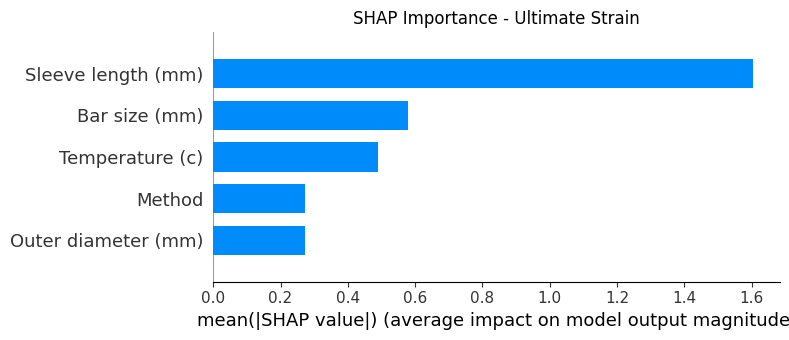

In [ ]:
##======== SHAP ANALYSIS ========

import shap
import matplotlib.pyplot as plt

# =============================================================================
# TRAIN FU MODEL
# =============================================================================

y_fu = df_clean["Ultimate strength (MPa)"]

model_fu = XGBRegressor(**params_fu)

model_fu.fit(
    X_train,
    y_fu.loc[X_train.index]
)

# =============================================================================
# SHAP FOR FU
# =============================================================================

explainer_fu = shap.TreeExplainer(model_fu)

shap_values_fu = explainer_fu.shap_values(X_train)

# -------------------- Summary Plot --------------------

shap.summary_plot(
    shap_values_fu,
    X_train,
    show=False
)

plt.title("SHAP Summary Plot - Ultimate Strength")
plt.tight_layout()
plt.show()

# -------------------- Bar Plot --------------------

shap.summary_plot(
    shap_values_fu,
    X_train,
    plot_type="bar",
    show=False
)

plt.title("SHAP Importance - Ultimate Strength")
plt.tight_layout()
plt.show()

# =============================================================================
# TRAIN EPS MODEL
# =============================================================================

y_eps = df_clean["Ultimate strain (%)"]

model_eps = XGBRegressor(**params_eps)

model_eps.fit(
    X_train,
    y_eps.loc[X_train.index]
)

# =============================================================================
# SHAP FOR EPS
# =============================================================================

explainer_eps = shap.TreeExplainer(model_eps)

shap_values_eps = explainer_eps.shap_values(X_train)

# -------------------- Summary Plot --------------------

shap.summary_plot(
    shap_values_eps,
    X_train,
    show=False
)

plt.title("SHAP Summary Plot - Ultimate Strain")
plt.tight_layout()
plt.show()

# -------------------- Bar Plot --------------------

shap.summary_plot(
    shap_values_eps,
    X_train,
    plot_type="bar",
    show=False
)

plt.title("SHAP Importance - Ultimate Strain")
plt.tight_layout()
plt.show()

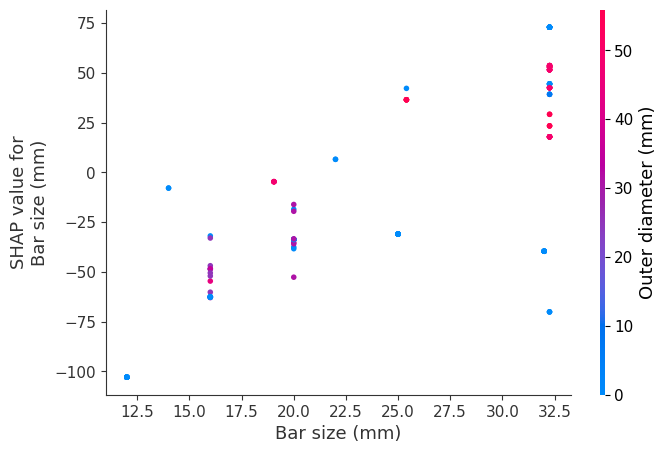

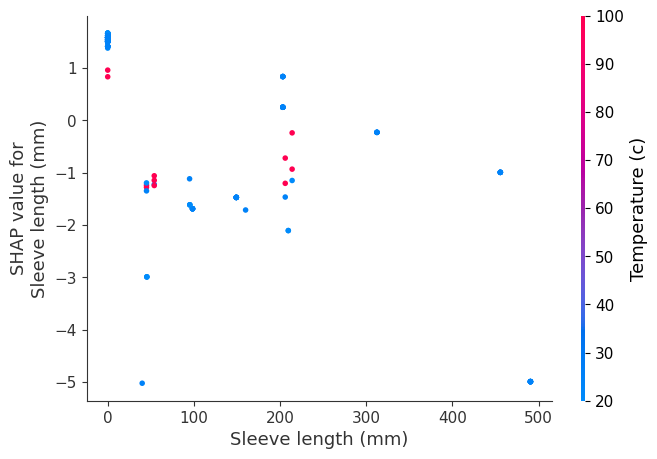

In [ ]:
## =============== Dependence Plots ===============

shap.dependence_plot(
    "Bar size (mm)",
    shap_values_fu,
    X_train
)


shap.dependence_plot(
    "Sleeve length (mm)",
    shap_values_eps,
    X_train
)

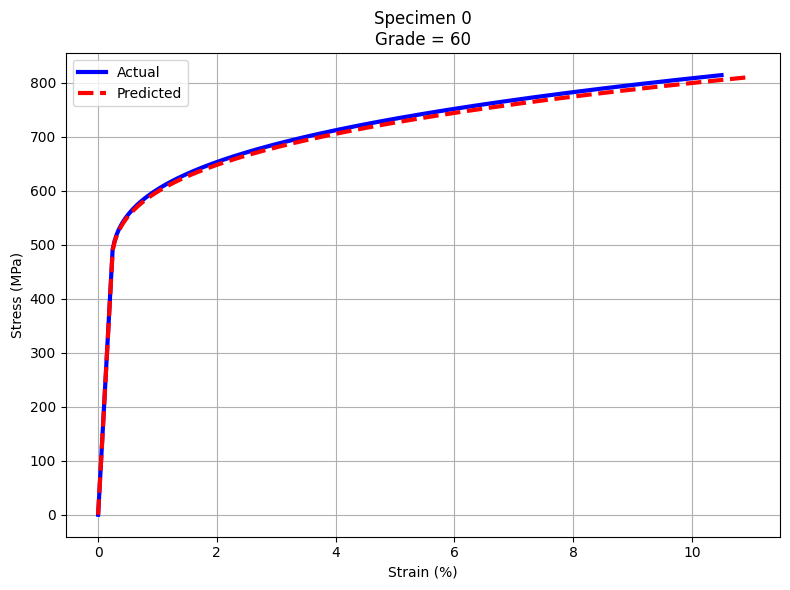

Grade = 60
fy = 420.0 MPa
ey = 0.00210

Actual fu = 814.3 MPa
Predicted fu = 810.2 MPa

Actual eu = 10.50%
Predicted eu = 10.94%


In [ ]:
# =============================================================================
# PHYSICS-INFORMED STRESS-STRAIN RECONSTRUCTION
# =============================================================================
#
# This method reconstructs the stress-strain curve of reinforcing bars using
# a hybrid Machine Learning (ML) and mechanics-based approach.
#
# Step 1:
# The reinforcement grade is used to determine the nominal yield stress (fy).
#
# Step 2:
# The elastic modulus is assumed as:
#       E = 200 GPa
#
# Step 3:
# The yield strain is calculated from:
#       ey = fy / E
#
# Step 4:
# XGBoost models predict:
#       fu = Ultimate Strength
#       eu = Ultimate Strain
#
# Step 5:
# A smooth strain-hardening branch is generated between the yield point
# (ey, fy) and ultimate point (eu, fu) using a power-law interpolation:
#
#       σ = fy + (fu - fy)
#           * ((ε - ey)/(eu - ey))^n
#
# where:
#       n = hardening shape parameter
#
#       n < 1  → rapid early hardening
#       n = 1  → linear hardening
#       n > 1  → delayed hardening
#
# The resulting framework generates a complete constitutive stress-strain
# curve using only:
#
#       Grade
#       Splice parameters
#       Predicted fu
#       Predicted eu
#
# without requiring direct prediction of yield stress.
# =============================================================================
# =============================================================================
# SMOOTH STRESS-STRAIN CURVE
#
# Actual Curve:
#     fy = Grade
#     fu = Experimental
#     eu = Experimental
#
# Predicted Curve:
#     fy = Grade
#     fu = ML
#     eu = ML
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# USER INPUT
# =============================================================================

row_id = 0

# =============================================================================
# SELECT SPECIMEN
# =============================================================================

sample = df_clean.iloc[[row_id]]

# =============================================================================
# PREPARE INPUT FOR ML
# =============================================================================

X_sample = sample[feature_cols]

X_sample = pd.get_dummies(X_sample)

X_sample = X_sample.reindex(
    columns=X_train.columns,
    fill_value=0
)

# =============================================================================
# GRADE → fy
# =============================================================================

grade = sample["Grade"].values[0]

grade_to_fy = {
    400: 400,
    500: 500,
    60: 420,
    75: 520
}

fy = grade_to_fy[grade]

# =============================================================================
# ELASTIC MODULUS
# =============================================================================

E = 200000.0

ey = fy / E

# =============================================================================
# ACTUAL VALUES
# =============================================================================

fu_real = sample["Ultimate strength (MPa)"].values[0]

eu_real = (
    sample["Ultimate strain (%)"].values[0]
    / 100
)

# =============================================================================
# PREDICTED VALUES
# =============================================================================

fu_pred = model_fu.predict(X_sample)[0]

eu_pred = (
    model_eps.predict(X_sample)[0]
    / 100
)

# =============================================================================
# SHAPE PARAMETER
# =============================================================================
#
# n controls curvature:
#
# n = 1.0 --> linear
# n = 0.5 --> rapid hardening
# n = 2.0 --> delayed hardening
#
# Try:
# 0.3 - 0.8
#
# =============================================================================

n = 0.3

# =============================================================================
# ACTUAL CURVE
# =============================================================================

strain_real_hard = np.linspace(
    ey,
    eu_real,
    300
)

stress_real_hard = fy + (
    fu_real - fy
) * (
    (strain_real_hard - ey)
    /
    (eu_real - ey)
)**n

strain_real = np.concatenate([
    np.linspace(0, ey, 50),
    strain_real_hard
])

stress_real = np.concatenate([
    E * np.linspace(0, ey, 50),
    stress_real_hard
])

# =============================================================================
# PREDICTED CURVE
# =============================================================================

strain_pred_hard = np.linspace(
    ey,
    eu_pred,
    300
)

stress_pred_hard = fy + (
    fu_pred - fy
) * (
    (strain_pred_hard - ey)
    /
    (eu_pred - ey)
)**n

strain_pred = np.concatenate([
    np.linspace(0, ey, 50),
    strain_pred_hard
])

stress_pred = np.concatenate([
    E * np.linspace(0, ey, 50),
    stress_pred_hard
])

# =============================================================================
# PLOT
# =============================================================================

plt.figure(figsize=(8,6))

plt.plot(
    strain_real * 100,
    stress_real,
    'b-',
    linewidth=3,
    label='Actual'
)

plt.plot(
    strain_pred * 100,
    stress_pred,
    'r--',
    linewidth=3,
    label='Predicted'
)

plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')

plt.title(
    f'Specimen {row_id}\n'
    f'Grade = {grade}'
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# =============================================================================
# RESULTS
# =============================================================================

print(f"Grade = {grade}")
print(f"fy = {fy:.1f} MPa")
print(f"ey = {ey:.5f}")

print(f"\nActual fu = {fu_real:.1f} MPa")
print(f"Predicted fu = {fu_pred:.1f} MPa")

print(f"\nActual eu = {eu_real*100:.2f}%")
print(f"Predicted eu = {eu_pred*100:.2f}%")